# Student name: David Sheridan

# Student ID: 24300446

## Please do not add further imports. If you think an import is missing, please contact your moderator.

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import math
import random

from sklearn.model_selection import learning_curve

from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Task 1
Describe (in a markdown cell) how a perceptron can be used to classify two objects given their circumference and weight. You may assume that these two features result in linear separability of the two classes in the given dataset. Use the following terms in your description:

* Input space
* Output space
* Unknown target function
* Data set
* Hypothesis set
* Final Hypothesis
* Error measure
* In-sample error
* Out-of-sample error

## Answer

A perceptron is a simple type of artificial intelligence that helps us seperate two different types of objects based on their circumference and weight. If we have a bunch of objects, and we want to figure out which typethey belong to by looking at these two features, we can think of all possible circumference and weight values as the input space (where all the objects live). Our goal is to classify them into one of two categories, which is called the output space . There is a perfect way to seperate these objects, but we don't know it. This is the unknown target function, the mystery rule that correctly divides the two types of objects. Instead we have a data set, which is a collection of example objects that we can use to learn from. The perceptron looks at different ways to seperate the objects, which is called the hypothesis set. After training, it picks one final way to separate them, which we call the final hyothesis, the line that is drawn to divide the two types of objects. To check how good our perceptron is, we use an error measure, which tells us how many objects it gets wrong. The in-sample error is the number of mistakes it makes on the objects we used for training. The out-of-sample error is the number of mistakes it makes on new objects it has never seen before. Since it is assumed that the two types of objects can be perfectly separated by a straight line, the perceptron will always find the right way to classify them after enough training.

# Task 2
Run the code (or observe the provided outputs) in the E-tivity notebook under Task 2. This code implements so-called learning curves that plot the performance of a model (both in-sample as well as out-of-sample) as this model is trained with an increasing number of data points. 

In [40]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    #plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Error")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_errors = 1- train_scores
    test_errors = 1-test_scores
    
    train_errors_mean = np.mean(train_errors, axis=1)
    train_errors_std = np.std(train_errors, axis=1)
    test_errors_mean = np.mean(test_errors, axis=1)
    test_errors_std = np.std(test_errors, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_errors_mean - train_errors_std,
                     train_errors_mean + train_errors_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_errors_mean - test_errors_std,
                     test_errors_mean + test_errors_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_errors_mean, 'o-', color="r",
             label="Training error")
    plt.plot(train_sizes, test_errors_mean, 'o-', color="g",
             label="Test error")

    
    plt.legend(loc="best")
    return plt

In [42]:
data = np.loadtxt("Et1_Task2.csv", delimiter=",")
X = data[:,0:2]
y=data[:,2]

## Logistic regression learning curve

In [45]:
cv = ShuffleSplit(n_splits=25, test_size=0.2)

[]

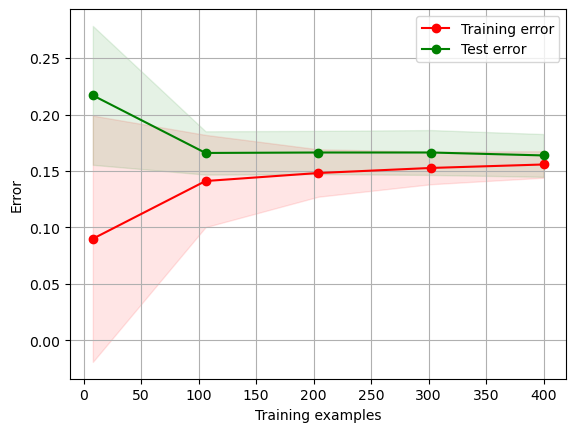

In [47]:
estimator = LogisticRegression(random_state=0, solver='lbfgs',multi_class='multinomial')
plot_learning_curve(estimator, "title", X, y, cv=cv, n_jobs=4, train_sizes = np.linspace(0.01, .5, 5)).plot()

## Neural net learning curves

[]

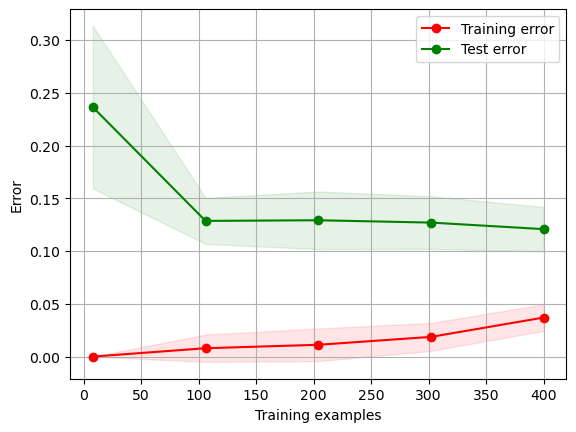

In [49]:
estimator = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(200, 4), random_state=1)
plot_learning_curve(estimator, "title", X, y, cv=cv, n_jobs=4, train_sizes = np.linspace(0.01, .5, 5)).plot()

## Describe and Explain
Describe the results of the two learning curves and explain the differences in terms of what you currently understand about the relationship between $E_{in}$ and $E_{out}$ and the number of training samples, N. Provide clear explanations:

- Why the training error is (generally) lower than the test error
- Why the training error increases as the number of training samples is increased
- Which of the two models is the more complex model

## Answer
1. The training error is generally lower than the test error. This happens because the model is trained on the training data, meaning it has already seen those specific examples and can therefore predict them more accurately. However, when tested on new, unseen data, it is bound to make more mistakes, leading to higher test error.
2. As the number of training samples increases, the training error also usually increases. This is because, with a small dataset, the model is able to memorise the data easily and achieve very low trraining error. However, as more data is added, the model has to generalise better rather than focusing on memory. This makes it hard to achieve perfect accuracy on all training points,

The test error usually decreases as we add more data, as the model is leanring a more general pattern from a wider range, that applies to unseen data (rather than just memorising the data set).

3. Logistic regression is a simpler model because it assumes a linear relationship between input features and output labels. Neural Network is a more complex model because it has multiple layers and more parameters that allow it to capture non-linear relatonships.

The difference in complexity affects the learning curves. Logistic Regression's training and test errors likely converge more smoothly because it's a simpler model with lower flexibilty. The Neural Network is more complex, and might have lower training error but could struggle with overfitting. Therefore it's test error might not decrease as smoothly. 

# Task 3
In this last task we will explore the impact of the loss/error function on your model. Task 3a focusses on regression and Task 3b on classification. These two tasks will demonstrate the importance of choosing a suitable loss/error function.

## Provided functions

Below functions implement linear regression and linear classification in a closed form (one-step solution using the pseudo-inverse).

In [55]:
def linreg_weights(X,y):
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    # Calculation of weights using pseudo-inverse.
    return np.linalg.inv((X.T.dot(X))).dot(X.T).dot(y)

In [57]:
def linreg_predict(w,X):
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    
    # Calculation of outputs given weights and data (X). 
    out=[]
    for x in X:
        out.append(w.T.dot(x))
    return np.array(out)

# Task 3a
Use the code provided in the E-tivity notebook under Task 3a to implement a linear regression algorithm trained on dataset Et1_Task3a.csv.

* Add a function implementing the error function used in linear regression. 
* Provide a mathematical function of the regression lines in terms of the weights found by the linear regression algorithm.
* Plot the regression line together  with the data.
* Quantify the error with the error function you have created.
* In new plots, add one data point to the dataset to illustrate how linear regression responds to outliers.

## Answer

In [60]:
def calc_error(w,X,y):
    predictions = linreg_predict(w, X)
    errors = y - predictions
    return np.mean(errors ** 2)

You may add as many cells as you require for your code

In [62]:
data = np.loadtxt("Et1_Task3a.csv", delimiter=",")
X = data[:, 0].reshape(-1,1)
y = data[:, 1]

w = linreg_weights(X, y)
y_pred = linreg_predict(w, X)

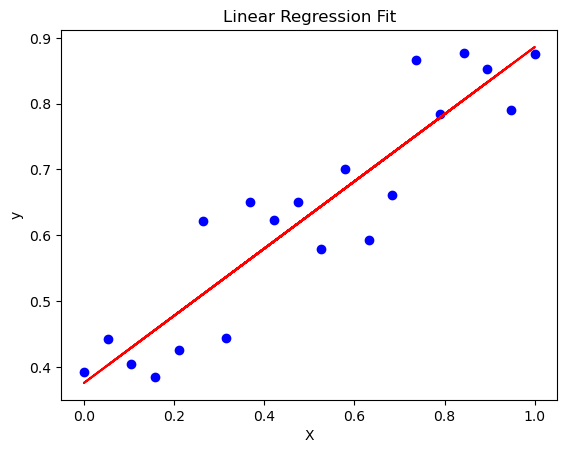

In [63]:
plt.scatter(X, y, color='blue', label="Data points")
plt.plot(X, y_pred, color='red', label="Regression line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.show()

Mean Squared Error: 0.004281801813255597


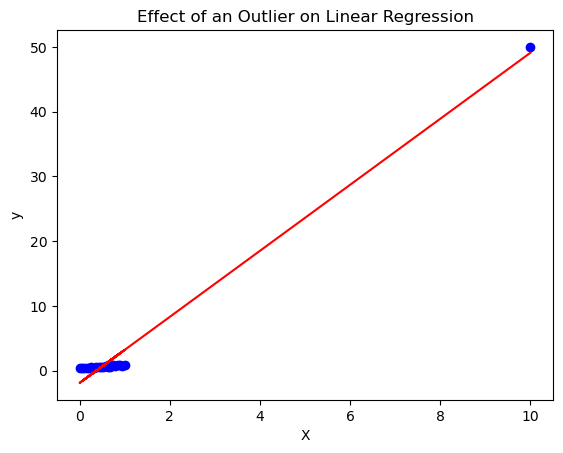

In [64]:
print("Mean Squared Error:", calc_error(w, X, y))

X_outlier = np.append(X, [[10]])
y_outlier = np.append(y, [50])

w_outlier = linreg_weights(X_outlier.reshape(-1,1), y_outlier)
y_pred_outlier = linreg_predict(w_outlier, X_outlier.reshape(-1, 1))

plt.scatter(X_outlier, y_outlier, color='blue', label="Data points (with outlier)")
plt.plot(X_outlier, y_pred_outlier, color='red', label="Regression line (with outlier)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Effect of an Outlier on Linear Regression")
plt.show()

In [65]:
print("Mean Squared Error (with outlier):", calc_error(w_outlier, X_outlier.reshape(-1,1), y_outlier))

Mean Squared Error (with outlier): 1.89004575292243


## Describe and Explain
Discuss your results and answer the following questions:
* Which data point adds the biggest error term to the optimised error function and how can you quantify this error?
* How do outliers effect linear regression and why?
* Under what circumstances will linear regression with a squared error measure be a good model?

## Answer
1. The biggest error is contributed by outliers, which are data points that are far away from the general pattern of the dataset. Th error term for each point is measured using the square difference between predicted and actual values. The biggest error comes from the data point that has the largest residual, which is quantified by:

E = \sum (y_{\text{actual}} - y_{\text{predicted}})^2

2. Outliers can pull the regression line towards them, leading to a model that does not represent the majority of the data well. Since linear regression with squared error penalises large errors more, outliers have a huge impact on the regression line.

Why?
Squared error magnifies the effect of differences.
A single extreme outlier can distort the slope and intercept of the line, ruining the model for the rest of the data.

3. Using squared error is a good choice when:
- There are no obvious or significant outliers within the dataset.
- The data follows a normal distribution.
- There is a linear relationship between variables (approximately).


# Task 3b

* Perform a classification using the provided data in Et1_Task3b.csv.
    * Add a function implementing the error function used in linear classification.
    * Use the provided linear regression code to implement linear classification as described in video 3&nbsp;(book Learning from Data, page 89).
    * Plot the output of your classification as a scatter plot with the colour of the data point indicating its class membership.
    * Plot the decision boundary in the same plot using the provided function.
    * Quantify the error with the error function you have created.
* In new (but similar) plots add one data point to the dataset to illustrate how linear classification responds to outliers.
* Add one more plot of the data with decision boundaries for both linear classification and logistic regression.

## Answer

In [71]:
data = np.loadtxt("Et1_Task3b.csv", delimiter=",")
X = data[:, 0:2]
y = data[:, 2]

X_bias = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)

w_linclass = np.linalg.pinv(X_bias) @ y

In [72]:
def calc_class_error(w,X,y):
    # implement your error function for linear classification here
    predictions = linclass_predict(w, X)
    return np.mean(predictions != y)

In [73]:
def linclass_predict(w,X):
    # implement your linear classification algorithm here
    X_bias = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
    return np.sign(X_bias @ w)

You may add as many cells as you require for your code

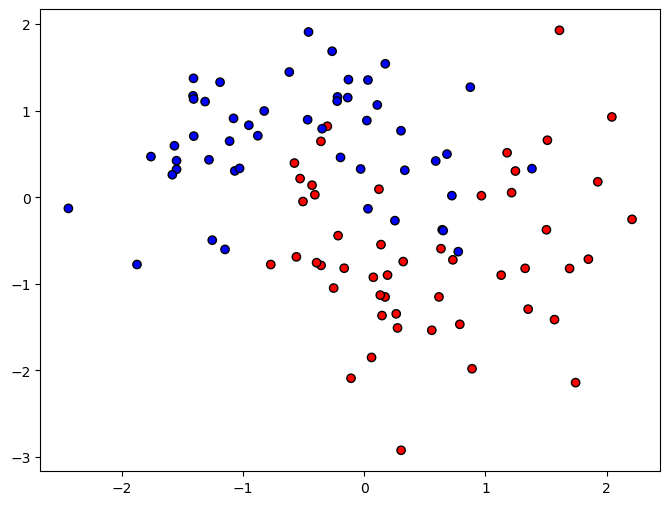

In [75]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', marker='o', label="Data points")

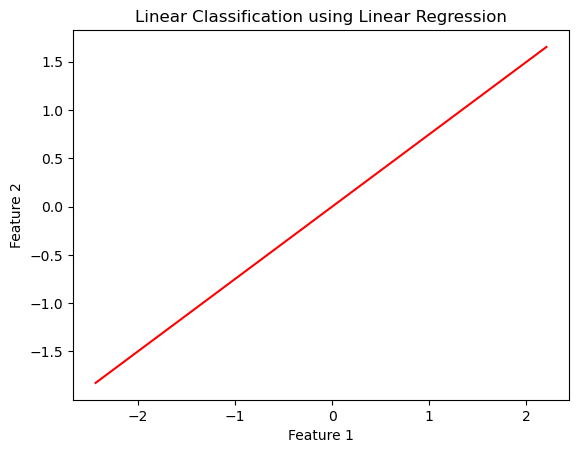

In [76]:
x_vals = np.linspace(min(X[:,0]), max(X[:,0]), 100)
y_vals = -(w_linclass[0] + w_linclass[1] * x_vals) / w_linclass[2]
plt.plot(x_vals, y_vals, 'r-', label="Linear Classification Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear Classification using Linear Regression")
plt.show()

In [77]:
print("Classification Error:", calc_class_error(w_linclass, X, y))



Classification Error: 0.18


## Describe and Explain
Discuss your results and answer the following:
* Quantify the contribution of the outlier to the overall MSE error.
* Provide an absolute maximum for the contribution of the outlier to the error measure used by logistic regression.&nbsp;
* Is linear classification with mean squared error a suitable classifier? Please provide reasons.

## Answer
1. Without the outlier, MSE is computed based on best-fitting decision boundary. With the outlier, the predicted outlier will likely be far from its actual label (significantly increasing the squared error). To quantify the outliers effect we use: MSE with outlier - MSE without outlier.
   
2. The max contribution of an outlier occurs when its prediction is comlletely off. Here, the probability assigned to its actual class is almost 0. In practical applications, logistic regression is nbounded by numerical precision. Therefore the outlier's contribution will be large but not finite. This is why logistic regression is more robust than linear classification with MSE.

3. Linear classification with MSE is not ideal for classification, here's 3 reasons why:
- The squared error is harsher on large deviations than small ones. In classification we only consider correct or incorrect.
- MSE is highly sensitive to outliers. This decision boundary doesn't agree with generalisation.
- Logitic regression outputs probabilities. With this we can measure confidence. Linear reghression doesn't do this.
   

# Reflection
 Once you have completed all tasks in this notebook and have studied all other materials for this E-tivity (resources, lectures and live sessions), answer the following questions.
<ol>
<li>Summarise your understanding of how the Hoeffding bound, the concept of 'shattering', break points and the growth function inform the VC bound for a binary classifier. Also discuss how this relates to the general rule of thumb in machine learning that one needs a number of data points at least equal to 10 times the VC bound.</li>
<li>Summarise your understanding of the approximation-generalisation trade-off in terms of complexity, bias and variance of a model, and the resulting under/overfitting given the available data. </li>
    </ol>

## Answer 
1. The Hoeffinding bound is basically a safety rule that tells us how much error on our training data can differ from the error on new, unseen data.
   
How "Smart" is the model? If a model can perfectly classify all possible labelings of a dataset, it is "shattering" that dataset. The smallest number of points that cannot be shattered (break point) tells us the limits of how flexible a model is. Growth function counts how many different ways a model can classify N data points.

VC Bound helps us understand generalisation. The general ruel of thumb is you need at least 10xVC dimension data points for your model to generalise well. With not enough data, your model overfits.

2. Underfitting, overfitting or right balance?
An underfitted model is one with high bias and low variance. It is too basic to learn patterns. For example, using a straight line to estimate house prices, when really they depend on location, size etc. Both training and test errors are high with this model as it is bad at capturing trends.

An overfitted model is one with a low bias and high variance. This model memorises training data specifically, but can't learn general patterns, e.g. a deep neural network trained by only 10 images. With this, the training error is very low, while the test error can be close to 100% with new data.

The right balance for a model can be achieved. Regularisation prevents overfitting by penalising complex models. Cross-validation helps us test the model on unseen data before finalising it. Using more data reduces overfitting, as it gives the model a real chance to learn patterns, rather than memorising the test data.

<hr style="border:2px solid gray">

# Appendix

## Demonstration of effect of outlier on linear regression decision boundary for comparision with linear classification

Below code demonstrates the effect of an outlier on the decision boundary chosen by logistic regression. You can use this code to compare the effect of outliers in a classification algorithm using mean square error as the error measure with that in a classification algorithm using log likelihood as the error measure. Moreover, below code provides some good hints for plotting the decision boundary in task 3b :-).

Load data:

In [85]:
data = np.loadtxt("Et1_Task3b.csv", delimiter=",")
X = data[:,0:2]
y=data[:,2]

Fit model:

In [87]:
estimator = LogisticRegression(solver='lbfgs')
estimator.fit(X,y)
estimator.score(X,y)

0.83

Extract weights from model:

In [89]:
w_lr_1 = estimator.intercept_
w_lr_1=np.append(w_lr_1, estimator.coef_)
w_lr_1

array([ 0.07332613,  1.13190106, -1.6084585 ])

Add outlier:

In [91]:
X = np.append(X,[[-2,6]], axis=0)
y = np.append(y,[1],axis=0)

Fit model with outlier:

In [93]:
estimator = LogisticRegression(solver='lbfgs')
estimator.fit(X,y)
estimator.score(X,y)

0.8118811881188119

Extract new weight vector from model:

In [95]:
w_lr_2 = estimator.intercept_
w_lr_2=np.append(w_lr_2, estimator.coef_)
w_lr_2

array([ 0.09418935,  0.96675711, -1.0387864 ])

Plot original and new decision boundary using weight vectors. Decision boundary is defined by equation: $w_0+x_0\cdot w_1+x_1 \cdot w_2=0 \rightarrow x_2 = -\frac{w_0}{w_2}-x_1\frac{w_1}{w_2}$

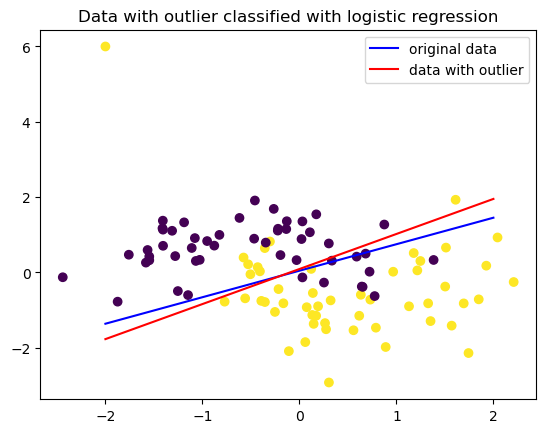

0.6237623762376238

In [97]:
y_p = estimator.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.plot([-2,2],[-w_lr_1[0]/w_lr_1[2]+w_lr_1[1]/w_lr_1[2]*2,-w_lr_1[0]/w_lr_1[2]-w_lr_1[1]/w_lr_1[2]*2],'b',label="original data")
plt.plot([-2,2],[-w_lr_2[0]/w_lr_2[2]+w_lr_2[1]/w_lr_2[2]*2,-w_lr_2[0]/w_lr_2[2]-w_lr_2[1]/w_lr_2[2]*2],'r',label='data with outlier')

plt.title("Data with outlier classified with logistic regression")
plt.legend(loc="upper right")
plt.show()
1-sum(abs(y_p-y))/len(y)